In [ ]:
import torch
import matplotlib.pyplot as plt
from torch.distributions import Normal, Uniform
from abracalibra.forward_model import ForwardModel
from gpytorch.models import ExactGP
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood
from gpytorch.means import Mean
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.distributions import MultivariateNormal
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from abracalibra.history_matching import HistoryMatchingBase
from abracalibra.summary import implausibility_univariate_distr

class EvenQuarticMean(Mean):
    def __init__(self,input_shape):
        super().__init__()
        self.a = torch.nn.Parameter(torch.zeros(input_shape)) # x^4
        self.b = torch.nn.Parameter(torch.zeros(input_shape)) # x^2
        self.c = torch.nn.Parameter(torch.tensor(0.0)) # c

    def forward(self, x):
        return (self.a*x**4).sum(dim=-1) + (self.b*x**2).sum(dim=-1) + self.c

class RosenbrockGP(ExactGP):
    def __init__(self, train_x, train_y):
        likelihood = FixedNoiseGaussianLikelihood(noise=torch.full_like(train_y,0.001))
        super(RosenbrockGP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = EvenQuarticMean(input_shape=train_x.shape[-1])
        self.covar_module = ScaleKernel(MaternKernel(nu=1.5,ard_num_dims=2))

    def forward(self,x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

class HistoryMatchingRosenbrock(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        if self.current_wave > 0: 
            valid_params = self.nroy(parameters[:-1],wave=self.current_wave)
            valid_old_params = parameters[:-1][valid_params,:]
            valid_old_obs = observations[:-1][valid_params,:]
            parameters = torch.cat([valid_old_params,parameters[-1]],dim=0)
            observations = torch.cat([valid_old_obs,observations[-1]],dim=0)

        parameters = parameters.view(-1,self.number_of_parameters)   
        observations = observations.view(-1,self.number_of_observables)
        if self.current_wave == 0:
            observations = observations.squeeze()
            model = RosenbrockGP(parameters.double(), observations.double())
            model.train()
            optim = torch.optim.Adam(model.parameters(), lr=0.1)
            mll = ExactMarginalLogLikelihood(model.likelihood, model)
            for i in range(500):

                optim.zero_grad()
                output = model(parameters)
                loss = -mll(output, observations)
                loss.backward()
                optim.step()
                print(f"Step {i} - Loss: {loss.item()}")
            model.eval()
            return model
        else:
            kernel = ScaleKernel(MaternKernel(nu=1.5,ard_num_dims=2))
            model = SingleTaskGP(parameters.double(), observations.double(),outcome_transform=None,covar_module=kernel)
            mll = ExactMarginalLogLikelihood(model.likelihood, model)
            fit_gpytorch_mll(mll)
            model.eval()
            return model

        
        

    

def rosenbrock(x,y,a=1,b=100):
    return (a-x)**2 + b*(y-x**2)**2


parameters = ["x", "y"]
priors = {"x": Uniform(0, 2), "y": Uniform(-2, 2)}

fwd_model = ForwardModel(rosenbrock, vectorized=True,a=1,b=100)


true_params = torch.tensor([1,1])
observables = Normal(torch.tensor(0.0),torch.tensor(0.001))






    

WAVE 0
Step 0 - Loss: 148905.15865388385
Step 1 - Loss: 135756.26984684984
Step 2 - Loss: 124693.19294413626
Step 3 - Loss: 115343.50476172232
Step 4 - Loss: 107344.08858926126
Step 5 - Loss: 100373.34909685978
Step 6 - Loss: 94186.45703660036
Step 7 - Loss: 88621.98054748638
Step 8 - Loss: 83580.17777107315
Step 9 - Loss: 78996.88065659654
Step 10 - Loss: 74825.62608879185
Step 11 - Loss: 71028.44974248859
Step 12 - Loss: 67571.67847492099
Step 13 - Loss: 64424.31430227405
Step 14 - Loss: 61557.4535055287
Step 15 - Loss: 58944.19819508033
Step 16 - Loss: 56559.57880234458
Step 17 - Loss: 54380.59956464691
Step 18 - Loss: 52386.241483353486
Step 19 - Loss: 50557.31285413636
Step 20 - Loss: 48876.5265889062
Step 21 - Loss: 47328.26919629755
Step 22 - Loss: 45898.58565937901
Step 23 - Loss: 44575.03495683356
Step 24 - Loss: 43346.575031157176
Step 25 - Loss: 42203.46012106378
Step 26 - Loss: 41137.132457219675
Step 27 - Loss: 40140.07624603492
Step 28 - Loss: 39205.74216363092
Step 29 - 

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:284: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/botorch/models/utils/assorted.py:268: InputDataWarning: Data (outcome observations) is not standardized (std = tensor([1.8096], dtype=torch.float64), mean = tensor([1.5400], dtype=torch.float64)).Please consider scaling the input to zero mean and unit variance.
  check_standardization(Y=train_Y, raise_on_fail=raise_on_fail)


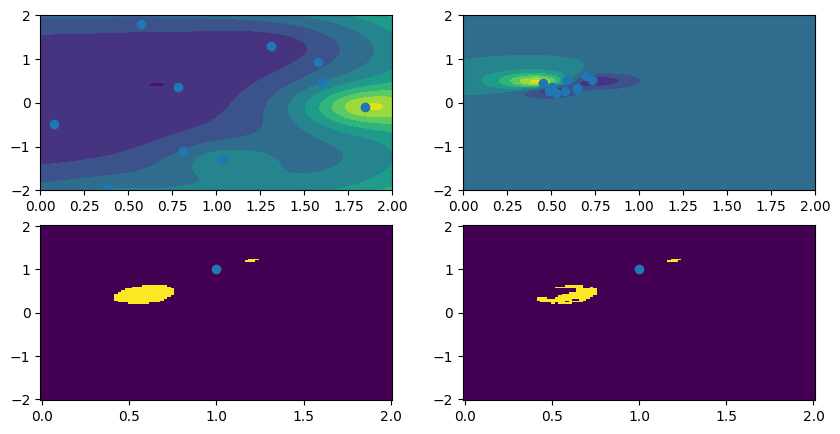

In [27]:
NWAVES = 2
fig,axs = plt.subplots(2,NWAVES,figsize=(10,5))
x,y = torch.meshgrid(torch.linspace(0,2,100),torch.linspace(-2,2,100),indexing='ij')
xy = torch.stack([x,y],dim=-1).reshape(-1,2)

hm = HistoryMatchingRosenbrock(
    parameters,
    priors,
    observables,
    implausibility_univariate_distr,
    ensemble_size=10,
    forward=fwd_model,
    implausibility_cutoff=3
)
for i,params in hm.hm_iter(NWAVES,verbose=True):
    print(f"WAVE {i}")
    if i > 0: 
        nroy = hm.nroy(xy)
        axs[1,i-1].pcolormesh(x,y,nroy.reshape(100,100))
        axs[1,i-1].scatter([1],[1])
    results = fwd_model(params)
    emulator = hm.step(results)
    with torch.no_grad():
        res_xy = emulator(xy)
        c = axs[0,i].contourf(x,y,res_xy.mean.reshape(100,100),levels=10)
        
        axs[0,i].scatter(params[:,0],params[:,1])


nroy = hm.nroy(xy)
axs[1,-1].pcolormesh(x,y,nroy.reshape(100,100))
axs[1,-1].scatter([1],[1])


In [ ]:
data = fwd_model(xy).reshape(100,100)
plt.contourf(x,y,data)
plt.colorbar()

tensor([[-2.0000, -1.9596, -1.9192,  ...,  1.9192,  1.9596,  2.0000],
        [-2.0000, -1.9596, -1.9192,  ...,  1.9192,  1.9596,  2.0000],
        [-2.0000, -1.9596, -1.9192,  ...,  1.9192,  1.9596,  2.0000],
        ...,
        [-2.0000, -1.9596, -1.9192,  ...,  1.9192,  1.9596,  2.0000],
        [-2.0000, -1.9596, -1.9192,  ...,  1.9192,  1.9596,  2.0000],
        [-2.0000, -1.9596, -1.9192,  ...,  1.9192,  1.9596,  2.0000]])

In [ ]:
fig, ax = plt.subplots()
nroy, (x, y) = hm.nroy_over_support(return_coords=True)
ax.pcolormesh(y, x, nroy)
ax.set_xlabel("y")
ax.set_ylabel("x")
ax.scatter(1, 1, color="red",label="True")
ax.legend()
fig.savefig("tests/test_history_matching_rosenbrock.png")

assert hm.params.shape == (NWAVES, 20, 2)
assert hm.results.shape == (NWAVES, 20, 1)
assert len(hm.emulators) == NWAVES
assert hm.current_wave == NWAVES
is_true_in_nroy = hm.nroy(torch.tensor([[1,1]]))
assert is_true_in_nroy